In [ ]:
pip install pandas

In [ ]:
pip install sentence-transformers

In [ ]:
pip install scikit-learn

In [ ]:
pip install nltk

In [ ]:
pip install emoji

In [ ]:
import pandas as pd
import re
import emoji
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import nltk

# Загрузка стоп-слов для русского языка
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Функция очистки текста
def clean_text(text):
    if isinstance(text, str) and text.strip():  # Проверяем, что текст — строка и не пустая
        text = emoji.replace_emoji(text, replace='')
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'[^\w\s]', '', text.lower())
        text = ' '.join(word for word in text.split() if word not in stop_words)
        return text
    return ''  # Возвращаем пустую строку для NaN, None или пустых строк

# Загрузка данных
try:
    df = pd.read_csv('dv_anisimov_comments-1.csv.csv', encoding='utf-8')
except FileNotFoundError:
    print("Файл comments.csv не найден. Проверьте, что он находится в той же папке, что и скрипт.")
    exit()

# Проверка данных
print("Первые строки DataFrame:")
print(df.head())
print("\nСтолбцы в DataFrame:", df.columns)
print("\nТипы данных в столбце 'comment':")
print(df['comment'].apply(type).value_counts())
print("\nПропущенные значения в столбце 'comment':")
print(df['comment'].isna().sum())

# Заменяем NaN на пустую строку
df['comment'] = df['comment'].fillna('')
# Применяем очистку
df['Cleaned_Comment'] = df['comment'].apply(clean_text)
# Удаляем пустые строки
df = df[df['Cleaned_Comment'].str.strip() != '']

Первые строки DataFrame:
                                             comment Unnamed: 1 Unnamed: 2  \
0  "Смотря где туалет, у драмтеатра закрыт, у пло...        NaN        NaN   
1  "Извиняюсь, что не в тему, но вопрос такой, у ...        NaN        NaN   
2  "Большое спасибо нашей УК, что не отключили от...        NaN        NaN   
3  "Дмитрий Викторович! Школу 19 в Кировском райо...        NaN        NaN   
4  "Надо вкладывать деньги в зоне сноса домов,где...        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9  ... Unnamed: 91 Unnamed: 92 Unnamed: 93 Unnamed: 94 Unnamed: 95  

In [ ]:
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

2_Dense/pytorch_model.bin:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

In [ ]:
embeddings = model.encode(df['Cleaned_Comment'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/190 [00:00<?, ?it/s]

In [ ]:
num_clusters = 9
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(embeddings)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Получаем центроиды кластеров
centroids = kmeans.cluster_centers_

# Вычисляем косинусную схожесть для каждого комментария
similarities = []
for i, embedding in enumerate(embeddings):
    cluster_id = df['Cluster'].iloc[i]
    similarity = cosine_similarity([embedding], [centroids[cluster_id]])[0][0]
    similarities.append(similarity)

df['Similarity'] = similarities

In [ ]:
print("Первые строки DataFrame с колонкой Similarity:")
print(df[['comment', 'Cleaned_Comment', 'Cluster', 'Similarity']].head(10))

Первые строки DataFrame с колонкой Similarity:
                                             comment  \
0  "Смотря где туалет, у драмтеатра закрыт, у пло...   
1  "Извиняюсь, что не в тему, но вопрос такой, у ...   
2  "Большое спасибо нашей УК, что не отключили от...   
3  "Дмитрий Викторович! Школу 19 в Кировском райо...   
4  "Надо вкладывать деньги в зоне сноса домов,где...   
5                                    " здравствуйте!   
6  Электронные часы на ТУРР спешат на час. 5 мину...   
7  В чате администрации города вчера выкладывали ...   
8  "А часики то стоят, что то не так с блоком упр...   
9  "Уважаемый Дмитрий Викторович. В ходе ремонта ...   

                                     Cleaned_Comment  Cluster  Similarity  
0  смотря туалет драмтеатра закрыт площади совето...        5    0.454351  
1  извиняюсь тему вопрос новые туалеты центре пра...        5    0.420392  
2  большое спасибо нашей ук отключили отопительну...        8    0.383862  
3  дмитрий викторович школу 19 к

In [ ]:
# Фильтрация запросов
request_keywords = ['хочу', 'нужно', 'сделайте','сделать', 'просим', 'требуется', 'изменить','изменили', 'отремонтировать', 'отремонтировали', 'создать','создали', 'обновить', 'обновили', 'исправить','исправили', 'оборудовать', 'оборудовали', 'убрать', 'убрали', 'запустили', 'починить','починили', 'открыть', 'открыли', 'закрыть','закрыли', 'восстановили','восстановить']


def is_urban_request(comment):
    has_request = any(keyword in comment.lower() for keyword in request_keywords)
    return has_request

# Проверка столбцов
print("Столбцы в DataFrame:", df.columns)

# Фильтруем только запросы, связанные с городской средой
df['Is_Urban_Request'] = df['comment'].apply(is_urban_request)  # Используем 'comment'
urban_requests = df[df['Is_Urban_Request'] == True]


Столбцы в DataFrame: Index(['comment', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 94', 'Unnamed: 95', 'Unnamed: 96', 'Unnamed: 97',
       'Unnamed: 98', 'Unnamed: 99', 'Unnamed: 100', 'Cleaned_Comment',
       'Cluster', 'Similarity'],
      dtype='object', length=104)


In [ ]:
# Классификация по категориям (Шаг 7)
urban_categories = {





    'Жилье и прилегающие пространства': ['двор', 'жилой фонд', 'здани', 'коммунальн', 'газ', 'электричеств', 'вод', 'труб', 'отопление', 'горячая вода', 'холодная вода', 'канализац', 'ливнёвк', 'парков', 'подъезд', 'шлагбаум'],
    'Озеленение территории': ['парк', 'сквер', 'озеленен', 'дерев', 'зелен', 'тен', 'насажден', 'трав', 'куст', 'вырубк', 'сухост', 'топол', 'ёлк', 'газон', 'клумб', 'трав','алле'],
    'Улично-дорожная сеть': ['дорог', 'светофор',  'мост', 'пробк', 'затор', 'тротуар', 'авари', 'дорожк', 'развязк', 'остановк', 'освещени', 'пешеход', 'знак', 'асфальт', 'соединить', 'коле', 'путепровод', 'ям', 'ремонт', 'светофор', 'разметк', 'переезд', 'перекрёсток', 'большегруз', 'водоотведени', 'лежачие полицейские'],
    'Доступность территорий': ['транспорт', 'велодорожк', 'парковк', 'связанност', 'пешеход', 'перемещ', 'доступност', 'пандус', 'бардюр', 'поребрик', 'автобус', 'трамва', 'троллейбус', 'соедин', 'интервал', 'маршрут', 'пересадк', 'выделенн'],
    'Экологическая ситуация': ['уборк', 'свалк', 'свалк', 'переработка', 'смог', 'воздух', 'дыш', 'сточн', 'загрязн', 'мусор', 'дым', 'уголь', 'выброс'],
    'Историко-культурное наследие': ['облик', 'статус', 'фасад', 'памятник', 'архитектура', 'скульптура', 'исторические', 'идентичность', 'классика'],
    'Социальная инфраструктура': ['школ', 'детск', 'поликлиник', 'больниц'],
    'Досуг/времяпрепровождение': ['спорт', 'площадк', 'ресторан', 'театр', 'кафе', 'музе', 'отдых', 'торгов', 'магазин', 'прогулк', 'досуг', 'заведени', 'площадк', 'парад', 'мероприяти']
}


Столбцы в DataFrame urban_requests: Index(['comment', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 95', 'Unnamed: 96', 'Unnamed: 97', 'Unnamed: 98',
       'Unnamed: 99', 'Unnamed: 100', 'Cleaned_Comment', 'Cluster',
       'Similarity', 'Is_Urban_Request'],
      dtype='object', length=105)
Первые строки DataFrame urban_requests:
                                              comment Unnamed: 1 Unnamed: 2  \
9   "Уважаемый Дмитрий Викторович. В ходе ремонта ...        NaN        NaN   
14  Посмотрим сколько провисят пластиковые часы. К...        NaN        NaN   
31  "Здравствуйте,в 74 микрорайоне, дорогу сделайт...        NaN        NaN   
47  "Так, что вот именно сейчас по ул. Ермака, 5 С...        NaN        NaN   
55  "Добрый день! На Коломейцева 3 должна была гор...        NaN        NaN   

   Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
9   

<ipython-input-17-9ab01e72f1f7>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  urban_requests['Category'] = urban_requests['comment'].apply(classify_category)


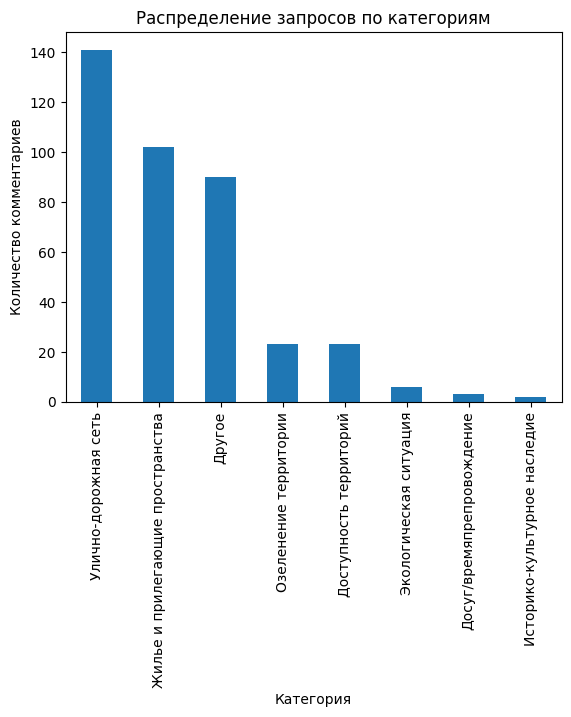

In [ ]:
def classify_category(comment):
    if isinstance(comment, str):
        for category, keywords in urban_categories.items():
            if any(keyword in comment.lower() for keyword in keywords):
                return category
        return 'Другое'
    return 'Другое'

# Проверка столбцов и данных
print("Столбцы в DataFrame urban_requests:", urban_requests.columns)
print("Первые строки DataFrame urban_requests:")
print(urban_requests.head())

urban_requests['Category'] = urban_requests['comment'].apply(classify_category)

# Проверка результатов
print("Первые строки с категориями:")
print(urban_requests[['comment', 'Cleaned_Comment', 'Category']].head(10))
print("\nРаспределение комментариев по категориям:")
print(urban_requests['Category'].value_counts())

# Визуализация
import matplotlib.pyplot as plt
urban_requests['Category'].value_counts().plot(kind='bar')
plt.title('Распределение запросов по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество комментариев')
plt.show()

# Сохранение результатов
urban_requests.to_csv('classified_urban_requests.csv', index=False, encoding='utf-8')